In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import Counter

import medmnist
from medmnist import INFO, Evaluator
from medmnist import DermaMNIST

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler
from medmnist import DermaMNIST

# from pytorch_grad_cam import GradCAM
# from pytorch_grad_cam.utils.image import show_cam_on_image
# from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [43]:
data_set = "dermamnist"
download = True

info = INFO[data_set]
task = info["task"] 
n_channels = info["n_channels"]
n_classes = len(info["label"])  
print(f"Task: {task}, Channels: {n_channels}, Number of classes: {n_classes}")

# change sizes here for different resolutions
train_dataset = DermaMNIST(split="train", download=False, size=28)
val_dataset = DermaMNIST(split="val", download=False, size=28)
test_dataset = DermaMNIST(split="test", download=False, size=28)

print(f"Number of training images: {len(train_dataset)}")
print(f"Number of validation images: {len(val_dataset)}")
print(f"Number of test images: {len(test_dataset)}")

Task: multi-class, Channels: 3, Number of classes: 7
Number of training images: 7007
Number of validation images: 1003
Number of test images: 2005


In [44]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [45]:
class_names = [info["label"][str(i)] for i in range(n_classes)]
datasets = [train_dataset, val_dataset, test_dataset]
dataset_names = ["train", "validation", "test"]

total_counter = Counter()
split_counters = {}

for i in range(3):
    count_labels = [int(label[0]) for _, label in datasets[i]]
    class_counts = Counter(count_labels)
    
    split_name = dataset_names[i]
    split_counters[split_name] = class_counts
    
    total_counter += class_counts

    print(f"[{split_name}] number of images per class:")
    print("-----")
    for j in range(n_classes):   
        count = class_counts[j]
        print(f"{class_names[j]}: {count}")
    print("-----")

total_images = sum(total_counter.values())
print("[total] number and proportions of images per class:")
print("-----")
for j in range(n_classes):
    count = total_counter[j]
    proportion = count / total_images
    print(f"{class_names[j]}: {count} ({proportion:.2%})")
print("-----")

rows = []
for j in range(n_classes):
    row = {
        "class": class_names[j],
        "train": split_counters["train"][j],
        "validation": split_counters["validation"][j],
        "test": split_counters["test"][j],
        "total": total_counter[j],
        "proportion": total_counter[j] / total_images
    }
    rows.append(row)

df = pd.DataFrame(rows)
df

[train] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 228
basal cell carcinoma: 359
benign keratosis-like lesions: 769
dermatofibroma: 80
melanoma: 779
melanocytic nevi: 4693
vascular lesions: 99
-----
[validation] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 33
basal cell carcinoma: 52
benign keratosis-like lesions: 110
dermatofibroma: 12
melanoma: 111
melanocytic nevi: 671
vascular lesions: 14
-----
[test] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 66
basal cell carcinoma: 103
benign keratosis-like lesions: 220
dermatofibroma: 23
melanoma: 223
melanocytic nevi: 1341
vascular lesions: 29
-----
[total] number and proportions of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 327 (3.27%)
basal cell carcinoma: 514 (5.13%)
benign keratosis-like lesions: 1099 (10.97%)
dermatofibroma: 115 (1.15%)
melanoma: 1113 (11.11%)
melanocytic nevi: 6705 (66.95%)
v

,class,train,validation,test,total,proportion
0,actinic keratoses and intraepithelial carcinoma,228,33,66,327,0.032651
1,basal cell carcinoma,359,52,103,514,0.051323
2,benign keratosis-like lesions,769,110,220,1099,0.109735
3,dermatofibroma,80,12,23,115,0.011483
4,melanoma,779,111,223,1113,0.111133
5,melanocytic nevi,4693,671,1341,6705,0.669496
6,vascular lesions,99,14,29,142,0.014179


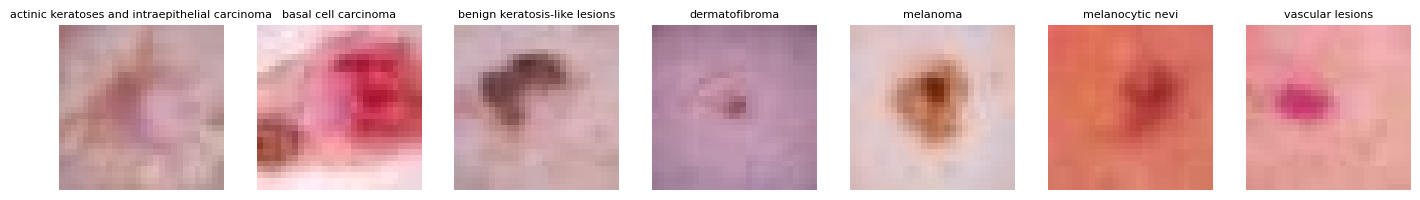

In [46]:
def show_one_per_class(dataset, class_names):
    n_classes = len(class_names)
    fig, axes = plt.subplots(1, n_classes, figsize=(2*n_classes, 2))

    if n_classes == 1:
        axes = [axes]
    
    shown_classes = set()
    for img, label in dataset:
        class_idx = int(label[0])
        
        if class_idx not in shown_classes:
            ax = axes[class_idx]
            
            if hasattr(img, "numpy"): 
                img_np = img.permute(1, 2, 0).numpy()
            else:  
                img_np = np.array(img)
            
            ax.imshow(img_np)
            ax.set_title(class_names[class_idx], fontsize=8)
            ax.axis("off")
            shown_classes.add(class_idx)
        
        if len(shown_classes) == n_classes:
            break

    plt.tight_layout()
    plt.show()

show_one_per_class(train_dataset, class_names)

In [47]:
# data imbalanced, nevi dominate with small counts for other classes
# benign classes: nevi, benign keratosis, dermatofibroma, vascular lesions
# malignant classes: melanoma, basal cell carcinoma
# pre-malignant / early stage: actinic keratoses and intraepithelial carcinoma

In [48]:
img, label = train_dataset[0]
print(np.array(img).shape)
info["n_channels"]

(28, 28, 3)


3

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

In [50]:
train_dataset = DermaMNIST(
    split="train",
    transform=train_transform,   
    download=True,
    size=28
)

val_dataset = DermaMNIST(
    split="val",
    transform=test_transform,
    download=True,
    size=28
)

test_dataset = DermaMNIST(
    split="test",
    transform=test_transform,
    download=True,
    size=28
)

In [51]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

n_classes = len(train_dataset.info["label"])

In [52]:
def get_resnet18():
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model.to(device)

def get_resnet50():
    model = models.resnet50(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model.to(device)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

def compute_auc(model, loader, split):
    model.eval()
    
    y_true = []
    y_score = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            y_true.append(labels.cpu())
            y_score.append(probs.cpu())

    y_true = torch.cat(y_true).numpy()
    y_score = torch.cat(y_score).numpy()

    evaluator = Evaluator("dermamnist", split)
    metrics = evaluator.evaluate(y_score)

    return metrics

In [53]:
train_labels = [int(label[0]) for _, label in train_dataset]
class_counts = np.bincount(train_labels)

print("Class counts:", class_counts)

class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum() * len(class_counts)

print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

Class counts: [ 228  359  769   80  779 4693   99]
Class weights: tensor([0.9426, 0.5987, 0.2795, 2.6865, 0.2759, 0.0458, 2.1709])


In [54]:
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        val_acc = evaluate(model, val_loader)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f} | Val Acc: {val_acc:.4f}")

    return model

In [55]:
resnet18 = get_resnet18()
resnet18 = train_model(resnet18, train_loader, val_loader, epochs=5)

test_acc_18 = evaluate(resnet18, test_loader)
print(f"ResNet18 Test Accuracy: {test_acc_18:.4f}")

val_auc_18 = compute_auc(resnet18, val_loader, split="val")
test_auc_18 = compute_auc(resnet18, test_loader, split="test")

print("ResNet18 Val Metrics:", val_auc_18)
print("ResNet18 Test Metrics:", test_auc_18)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Loss: 183.9641 | Val Acc: 0.4028
Epoch 2/5 | Loss: 155.9876 | Val Acc: 0.5444
Epoch 3/5 | Loss: 147.4455 | Val Acc: 0.5404
Epoch 4/5 | Loss: 146.6199 | Val Acc: 0.4427
Epoch 5/5 | Loss: 139.7570 | Val Acc: 0.5464
ResNet18 Test Accuracy: 0.5706
ResNet18 Val Metrics: Metrics(AUC=0.865473863809233, ACC=0.5463609172482552)
ResNet18 Test Metrics: Metrics(AUC=0.8656738716395772, ACC=0.570573566084788)


In [56]:
resnet50 = get_resnet50()
resnet50 = train_model(resnet50, train_loader, val_loader, epochs=5)

test_acc_50 = evaluate(resnet50, test_loader)
print(f"ResNet50 Test Accuracy: {test_acc_50:.4f}")

val_auc_50 = compute_auc(resnet50, val_loader, split="val")
test_auc_50 = compute_auc(resnet50, test_loader, split="test")

print("ResNet50 Val Metrics:", val_auc_50)
print("ResNet50 Test Metrics:", test_auc_50)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Loss: 214.8794 | Val Acc: 0.4706
Epoch 2/5 | Loss: 156.2641 | Val Acc: 0.5254
Epoch 3/5 | Loss: 142.9720 | Val Acc: 0.4826
Epoch 4/5 | Loss: 135.9264 | Val Acc: 0.6132
Epoch 5/5 | Loss: 146.9839 | Val Acc: 0.0688
ResNet50 Test Accuracy: 0.0618
ResNet50 Val Metrics: Metrics(AUC=0.6570953132264685, ACC=0.06879361914257229)
ResNet50 Test Metrics: Metrics(AUC=0.6319545852603798, ACC=0.061845386533665836)


In [57]:
# https://github.com/Peachypie98/CBAM
import torch.nn.functional as F

class CAM(nn.Module):
    def __init__(self, channels, r=16):
        super().__init__()

        self.linear = nn.Sequential(
            nn.Linear(channels, channels // r),
            nn.ReLU(inplace=True),
            nn.Linear(channels // r, channels)
        )

    def forward(self, x):
        max_pool = F.adaptive_max_pool2d(x, 1)
        avg_pool = F.adaptive_avg_pool2d(x, 1)

        b, c, _, _ = x.size()

        max_out = self.linear(max_pool.view(b, c)).view(b, c, 1, 1)
        avg_out = self.linear(avg_pool.view(b, c)).view(b, c, 1, 1)

        attention = torch.sigmoid(max_out + avg_out)
        return attention * x


class SAM(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)

    def forward(self, x):
        max_pool = torch.max(x, dim=1, keepdim=True)[0]
        avg_pool = torch.mean(x, dim=1, keepdim=True)

        concat = torch.cat([max_pool, avg_pool], dim=1)
        attention = torch.sigmoid(self.conv(concat))

        return attention * x


class CBAM(nn.Module):
    def __init__(self, channels, r=16):
        super().__init__()
        self.cam = CAM(channels, r)
        self.sam = SAM()

    def forward(self, x):
        out = self.cam(x)
        out = self.sam(out)
        return out + x

In [58]:
class ResNet_CBAM(nn.Module):
    def __init__(self, model_name, n_classes):
        super().__init__()

        if model_name == "resnet18":
            self.backbone = models.resnet18(pretrained=True)
        elif model_name == "resnet50":
            self.backbone = models.resnet50(pretrained=True)

        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.attention = CBAM(num_features)
        self.classifier = nn.Linear(num_features, n_classes)

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        x = self.attention(x)

        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [59]:
resnet18_cbam = ResNet_CBAM("resnet18", n_classes).to(device)
resnet18_cbam = train_model(resnet18_cbam, train_loader, val_loader, epochs=5)

test_acc_18_cbam = evaluate(resnet18_cbam, test_loader)
print(f"ResNet18 Test Accuracy: {test_acc_18_cbam:.4f}")

val_auc_18_cbam = compute_auc(resnet18_cbam, val_loader, split="val")
test_auc_18_cbam = compute_auc(resnet18_cbam, test_loader, split="test")

print("ResNet18 Val Metrics:", val_auc_18_cbam)
print("ResNet18 Test Metrics:", test_auc_18_cbam)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Loss: 193.2445 | Val Acc: 0.5763
Epoch 2/5 | Loss: 162.6386 | Val Acc: 0.5374
Epoch 3/5 | Loss: 149.0570 | Val Acc: 0.5454
Epoch 4/5 | Loss: 146.3176 | Val Acc: 0.5902
Epoch 5/5 | Loss: 142.9137 | Val Acc: 0.5593
ResNet18 Test Accuracy: 0.5800
ResNet18 Val Metrics: Metrics(AUC=0.8826980919929792, ACC=0.559322033898305)
ResNet18 Test Metrics: Metrics(AUC=0.8766252432839103, ACC=0.5800498753117207)


In [60]:
resnet18_cbam = ResNet_CBAM("resnet18", n_classes).to(device)
resnet18_cbam = train_model(resnet18_cbam, train_loader, val_loader, epochs=5, lr=1e-4)

test_acc_18_cbam = evaluate(resnet18_cbam, test_loader)
print(f"ResNet18 Test Accuracy: {test_acc_18_cbam:.4f}")

val_auc_18_cbam = compute_auc(resnet18_cbam, val_loader, split="val")
test_auc_18_cbam = compute_auc(resnet18_cbam, test_loader, split="test")

print("ResNet18 Val Metrics:", val_auc_18_cbam)
print("ResNet18 Test Metrics:", test_auc_18_cbam)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Loss: 190.1782 | Val Acc: 0.4586
Epoch 2/5 | Loss: 150.4214 | Val Acc: 0.5593
Epoch 3/5 | Loss: 141.5367 | Val Acc: 0.5912
Epoch 4/5 | Loss: 130.1660 | Val Acc: 0.5125
Epoch 5/5 | Loss: 123.8980 | Val Acc: 0.5703
ResNet18 Test Accuracy: 0.5721
ResNet18 Val Metrics: Metrics(AUC=0.8866894531592522, ACC=0.5702891326021934)
ResNet18 Test Metrics: Metrics(AUC=0.8826771386711902, ACC=0.5720698254364089)


In [61]:
resnet50_cbam = ResNet_CBAM("resnet50", n_classes).to(device)
resnet50_cbam = train_model(resnet50_cbam, train_loader, val_loader, epochs=5)

test_acc_50_cbam = evaluate(resnet50_cbam, test_loader)
print(f"ResNet50 Test Accuracy: {test_acc_50_cbam:.4f}")

val_auc_50_cbam = compute_auc(resnet50_cbam, val_loader, split="val")
test_auc_50_cbam = compute_auc(resnet50_cbam, test_loader, split="test")

print("ResNet50 Val Metrics:", val_auc_50_cbam)
print("ResNet50 Test Metrics:", test_auc_50_cbam)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Loss: 192.7601 | Val Acc: 0.3998
Epoch 2/5 | Loss: 156.6435 | Val Acc: 0.5344
Epoch 3/5 | Loss: 153.8852 | Val Acc: 0.4397
Epoch 4/5 | Loss: 179.6058 | Val Acc: 0.4995
Epoch 5/5 | Loss: 155.9894 | Val Acc: 0.3111
ResNet50 Test Accuracy: 0.3446
ResNet50 Val Metrics: Metrics(AUC=0.8357957040367027, ACC=0.31106679960119643)
ResNet50 Test Metrics: Metrics(AUC=0.8177432855079433, ACC=0.34463840399002493)


In [62]:
resnet50_cbam = ResNet_CBAM("resnet50", n_classes).to(device)
resnet50_cbam = train_model(resnet50_cbam, train_loader, val_loader, epochs=5, lr=1e-4)

test_acc_50_cbam = evaluate(resnet50_cbam, test_loader)
print(f"ResNet50 Test Accuracy: {test_acc_50_cbam:.4f}")

val_auc_50_cbam = compute_auc(resnet50_cbam, val_loader, split="val")
test_auc_50_cbam = compute_auc(resnet50_cbam, test_loader, split="test")

print("ResNet50 Val Metrics:", val_auc_50_cbam)
print("ResNet50 Test Metrics:", test_auc_50_cbam)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Loss: 193.1371 | Val Acc: 0.5324
Epoch 2/5 | Loss: 151.0377 | Val Acc: 0.5703
Epoch 3/5 | Loss: 143.1135 | Val Acc: 0.5324
Epoch 4/5 | Loss: 124.5823 | Val Acc: 0.5803
Epoch 5/5 | Loss: 116.7247 | Val Acc: 0.6690
ResNet50 Test Accuracy: 0.6843
ResNet50 Val Metrics: Metrics(AUC=0.9091439879903431, ACC=0.6689930209371885)
ResNet50 Test Metrics: Metrics(AUC=0.9154543077854914, ACC=0.68428927680798)


In [1]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib as mpl

def run_gradcam_grid(model, dataset, indices):
    model.eval()
    target_layer = model.backbone.layer4[-1]
    cam = GradCAM(model=model, target_layers=[target_layer])

    fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 5))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        img, label = dataset[idx]
        input_tensor = img.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_tensor)
            pred = output.argmax(dim=1).item()

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(pred)]
        )[0]

        rgb_img = img.permute(1, 2, 0).cpu().numpy()
        rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        ax.imshow(visualization)
        ax.set_title(f"Idx {idx}\nT:{label} P:{pred}")
        ax.axis("off")

    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])

    norm = mpl.colors.Normalize(vmin=0, vmax=1)
    sm = mpl.cm.ScalarMappable(cmap="jet", norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Attention intensity (Grad-CAM)", rotation=90, labelpad=12)

    plt.show()

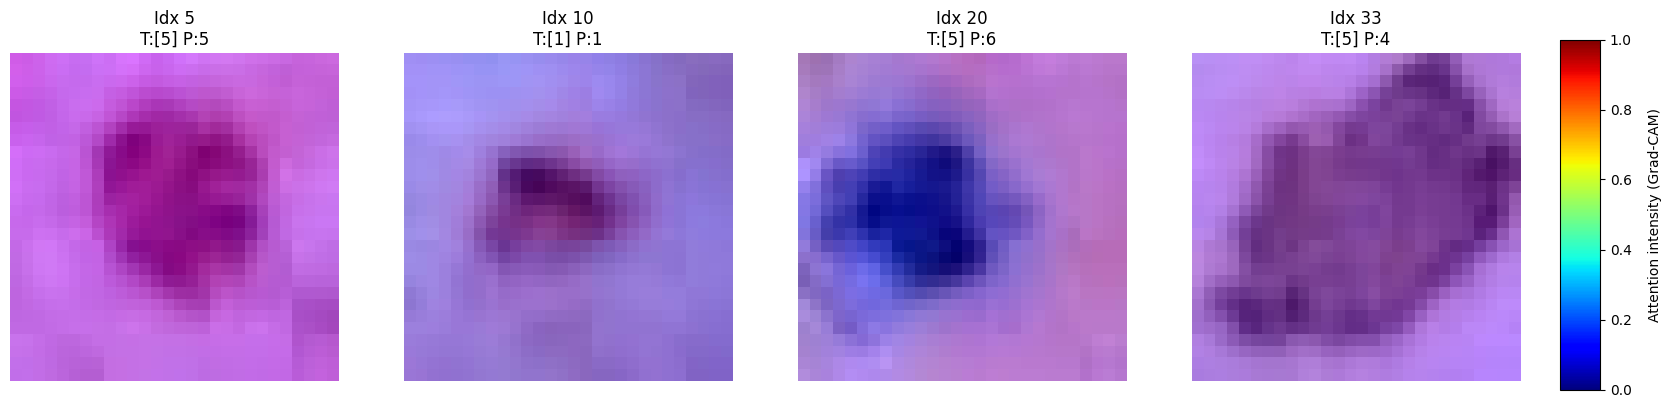

In [74]:
run_gradcam_grid(resnet18_cbam, test_dataset, [5, 10, 20, 33])